In [5]:
import xarray as xr 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd 


In [6]:
shapefile_path = r'D:\programing\Python_lab\Delhi shapefile-20260225T040519Z-1-001\Delhi shapefile/Delhi.shp'
shapefile1 = gpd.read_file(shapefile_path)

In [7]:
shapefile1['geometry'].head()

0    POLYGON ((76.20932 28.99355, 76.2121 28.99992,...
Name: geometry, dtype: geometry

In [10]:
mfdata_DIR =r'D:\programing\Python_lab\day5\drive-download-20260211T061511Z-1-001/gpm*'
df=xr.open_mfdataset(mfdata_DIR, parallel = True)
df

<xarray.Dataset> Size: 17MB
Dimensions:           (time: 48, lon: 274, lat: 331)
Coordinates:
  * time              (time) datetime64[ns] 384B 2018-06-09 ... 2018-06-09T23...
  * lon               (lon) float32 1kB 68.95 69.05 69.15 ... 96.05 96.15 96.25
  * lat               (lat) float32 1kB 5.35 5.45 5.55 ... 38.15 38.25 38.35
Data variables:
    precipitationCal  (time, lon, lat) float32 17MB dask.array<chunksize=(1, 274, 239), meta=np.ndarray>
Attributes:
    CDI:                                    Climate Data Interface version 1....
    Conventions:                            CF-1.6
    Original_Producer_Metadata_FileHeader:  DOI=10.5067/GPM/IMERG/3B-HH/06;\n...
    Original_Producer_Metadata_FileInfo:    DataFormatVersion=6a;\nTKCodeBuil...
    Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
    InputPointer:                           3B-HHR.MS.MRG.3IMERG.20180609-S00...
    history_L34RS:                          'Created by L34RS v1.4.3 @ NASA G...
    CDO:                                    Climate Data Operators version 1....

In [13]:
#cropping data to required lat-lon extent
min_lon = 75.50
min_lat = 26.50
max_lon = 79.00
max_lat = 30.00

df1 = df.sel(lat=slice(min_lat,max_lat), lon=slice(min_lon,max_lon))

In [14]:
pricp=df1.precipitationCal
#time=df1.time

In [15]:
lat=df1.lat
lon=df1.lon

In [18]:
pricp2=np.cumsum(pricp,axis=0)
pricp3=pricp2[45,:,:]
pricp3.shape

(35, 35)

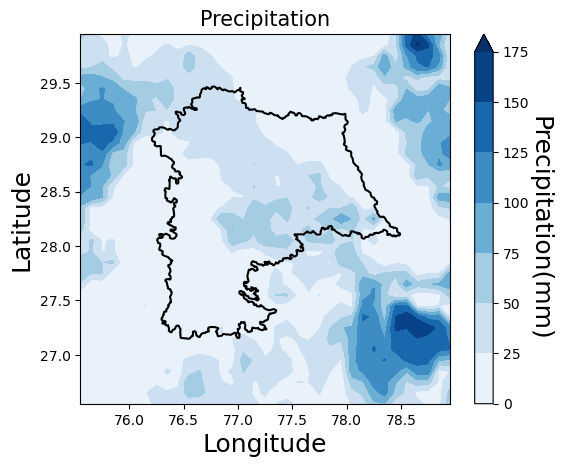

In [19]:
### precipitation contour plot
ax= plt.contourf(lon,lat,pricp3,cmap='Blues', extend='max')
cbar=plt.colorbar(ax)
#plt.clim(0,7)
cbar.set_label('Precipitation(mm)', fontsize= 18,rotation=270, labelpad=16)
plt.xlabel('Longitude', fontsize =18)
plt.ylabel('Latitude', fontsize =18)
plt.title('Precipitation', fontsize =15)
ax=shapefile1.boundary.plot(ax=plt.gca(),color='k')
plt.savefig(r'D:\programing\Python_lab\Delhi shapefile-20260225T040519Z-1-001/Day_6.tiff')
plt.show()